In [2]:
# %%
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None)


 # Part 1. Hypotheses prioritization

In [2]:
# %%
#hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypotheses_us.csv', sep=";")
hypothesis = pd.read_csv("hypotheses_us.csv", sep=";")
print(hypothesis)


                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on ...      5       3   
7  Add a subscription form to all the main pages....     10       7   
8  Launch a promotion that gives users discounts ...      1       9   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  
5           2       3  
6           8       3  
7           8       5  
8           9       5  


In [3]:
# %%
hypothesis['ICE'] = hypothesis['Impact']*hypothesis['Confidence']/hypothesis['Effort']
hypothesis['RICE'] = hypothesis['Reach']*hypothesis['Impact']*hypothesis['Confidence']/hypothesis['Effort']


In [4]:
# %%
print(hypothesis.sort_values(by='ICE', ascending=False))
print(hypothesis.sort_values(by='RICE', ascending=False))


                                          Hypothesis  Reach  Impact  \
8  Launch a promotion that gives users discounts ...      1       9   
0  Add two new channels for attracting traffic. T...      3      10   
7  Add a subscription form to all the main pages....     10       7   
6  Show banners with current offers and sales on ...      5       3   
2  Add product recommendation blocks to the store...      8       3   
1  Launch your own delivery service. This will sh...      2       5   
5  Add a customer review page. This will increase...      3       2   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort        ICE   RICE  
8           9       5  16.200000   16.2  
0           8       6  13.333333   40.0  
7           8       5  11.200000  112.0  
6           8       3   8.000000   40.0  
2           7       3   7.000000   56.0  
1           4      10   2.000000    4

 The priority of these hypotheses changes respective of the prioritization framework used.



 Hypothesis #8 has the highest priority when ICE is used, but gets average results with RICE, as despite having high Impact and Confidence values, its Reach is very low.



 This case demonstrates the difference between the two frameworks. When you take Reach into account, the priority may rise for some hypotheses (e.g., hypotheses 7,2), and fall for others (e.g., hypotheses 8,0)

 # Part 2. A/B test analysis

 ## Preparing data

In [3]:
# %%
#orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders_us.csv', sep=',')
orders = pd.read_csv('orders_us.csv', sep=',')
orders['date'] = orders['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

#visitors = pd.read_csv('https://code.s3.yandex.net/datasets/visitors_us.csv', sep=',')
visitors = pd.read_csv('visits_us.csv', sep=',')
visitors['date'] = visitors['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

print(orders.head(5))
print(visitors.head(5))


   transactionId   visitorId       date  revenue group
0     3667963787  3312258926 2019-08-15     30.4     B
1     2804400009  3642806036 2019-08-15     15.2     B
2     2961555356  4069496402 2019-08-15     10.2     A
3     3797467345  1196621759 2019-08-15    155.1     B
4     2282983706  2322279887 2019-08-15     40.5     B
        date group  visits
0 2019-08-01     A     719
1 2019-08-02     A     619
2 2019-08-03     A     507
3 2019-08-04     A     717
4 2019-08-05     A     756


In [4]:
#IRA: explorar visitantes en dos grupos
ord_grouped = orders.groupby("visitorId")["group"].unique()
ord_grouped

visitorId
5114589          [B]
6958315          [B]
8300375       [B, A]
11685486         [A]
39475350         [B]
               ...  
4266935830    [A, B]
4278982564       [A]
4279090005       [B]
4281247801       [B]
4283872382       [B]
Name: group, Length: 1031, dtype: object

In [5]:
#IRA: cantidad de usuarios en mas de 1 grupo
print("Cantidad de usuarios en más de 1 grupo: " , ord_grouped[ord_grouped.apply(lambda x: len(x) > 1)].shape[0])

porcentaje = round( (ord_grouped[ord_grouped.apply(lambda x: len(x) > 1)].shape[0]) / len(ord_grouped)*100,2 )
print("porcentaje de usuarios en más de 1 grupo: ", porcentaje, "%")

Cantidad de usuarios en más de 1 grupo:  58
porcentaje de usuarios en más de 1 grupo:  5.63 %


In [9]:
# %%
datesGroups = orders[['date','group']].drop_duplicates()

ordersAggregated = datesGroups.apply(
lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])].agg({
    'date' : 'max',
    'group' : 'max',
    'transactionId' : pd.Series.nunique,
    'visitorId' : pd.Series.nunique,
    'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

visitorsAggregated = datesGroups.apply(
lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group'] == x['group'])].agg({
'date' : 'max',
'group' : 'max',
'visits' : 'sum'}), axis=1).sort_values(by=['date','group'])

cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

print(cumulativeData.head(5))


        date group  orders  buyers  revenue  visitors
0 2019-08-01     A      24      20   2356.8       719
1 2019-08-01     B      21      20   1620.0       713
2 2019-08-02     A      44      38   3860.3      1338
3 2019-08-02     B      45      43   4243.8      1294
4 2019-08-03     A      68      62   5675.5      1845


In [8]:
# %%
print(orders['date'].min())
print(orders['date'].max())
print(len(orders))


2019-08-01 00:00:00
2019-08-31 00:00:00
1197


 ## Plotting graphs

 ### Ploting a cumulative revenue graph by groups

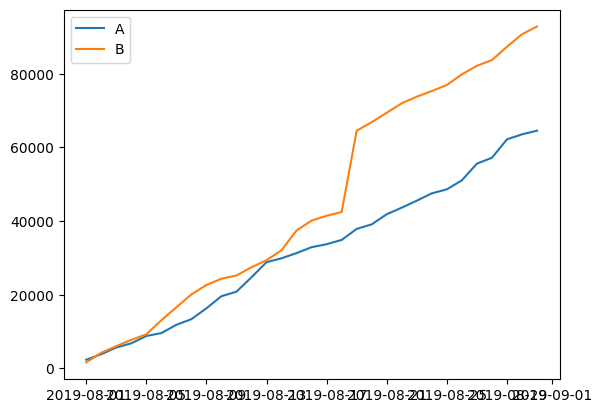

In [9]:
# %%
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')
plt.legend()


 Towards the middle of the test group В has considerably increased its revenue as compared to group A, but then kept growing at the same pace as group A. This may imply that there was at least one expensive order at the time



 ### Plotting a cumulative average order size graph by groups and its relative difference

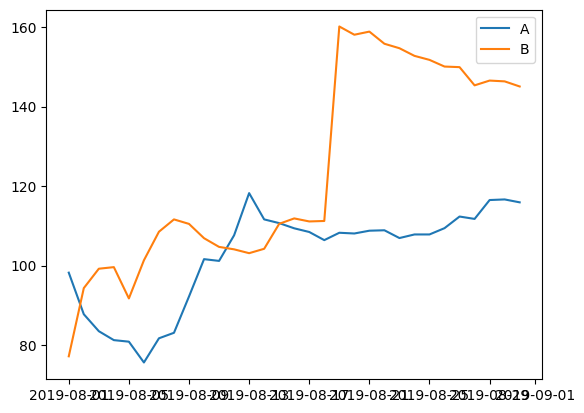

In [10]:
# %%
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')
plt.legend()



 We may draw the same conclusions as from the cumulative revenue graph. We can see that the value of average order size in group B began decreasing and normalizing but is still far from being equalized. This must be accounted for when making a decision on the A/B test results.

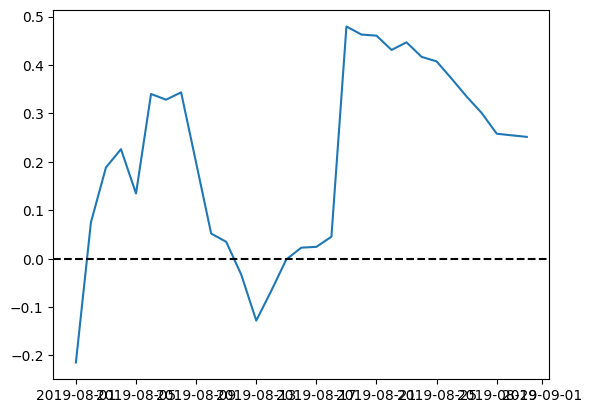

In [11]:
# %%
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)
plt.axhline(y=0, color='black', linestyle='--')


 We may draw the same conclusions as from the graphs with the average order size and revenue. Moreover, we observe strong fluctuations in the first half of the test.

 ### Plotting a cumulative conversion graph by groups and its relative difference

(18109.0, 18139.0, 0.0, 0.04)

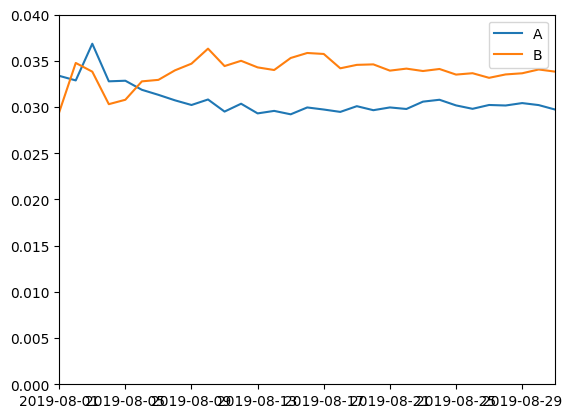

In [13]:
#original code
# cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
# cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
# plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
# plt.legend()
# plt.axis(["2019-08-01", '2019-08-31', 0, 0.04]) # TODO FIXME

#posible solution
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

start_date = pd.to_datetime("2019-08-01")
end_date = pd.to_datetime("2019-08-31")

plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()
plt.axis([start_date, end_date, 0, 0.04])

 Group B forged ahead at the beginning of the test and remained a leader in conversion throughout the whole test

(18109.0, 18139.0, -0.25, 0.25)

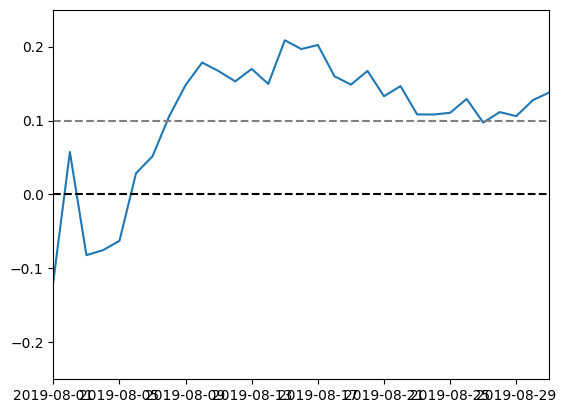

In [15]:
# %%
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.plot(mergedCumulativeConversions['date'], mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1)
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')
plt.axis([start_date, end_date, -0.25, 0.25])


 We come to the same conclusion. However, we can see that starting from the second half of the test the differences in conversion in group B decreases as compared to group A and is likely to equalize.

 ## Analyzing anomalies

 ### Anomalous users by the number of orders

          userId  orders
1023  4256040402      11
591   2458001652      11
569   2378935119       9
487   2038680547       8
44     199603092       5
744   3062433592       5
55     237748145       5
917   3803269165       5
299   1230306981       5
897   3717692402       5


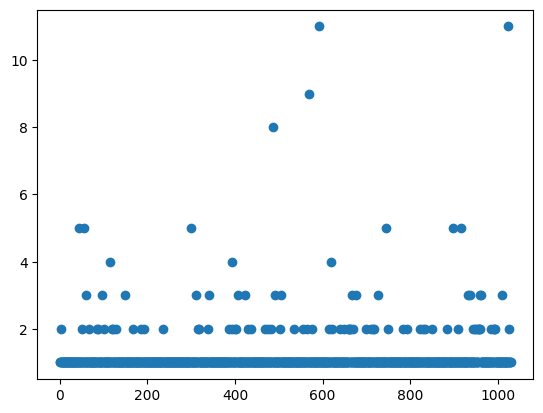

In [16]:
# %%
ordersByUsers = orders.drop(['group', 'revenue', 'date'], axis=1).groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})

ordersByUsers.columns = ['userId','orders']

print(ordersByUsers.sort_values(by='orders',ascending=False).head(10))

x_values = pd.Series(range(0,len(ordersByUsers)))

plt.scatter(x_values, ordersByUsers['orders'])


 The graph shows that the 3-4 orders per user is the limit for regular users.

 Let's calculate the 95th and 99th percentiles of the number of orders per user.

In [17]:
# %%
np.percentile(ordersByUsers['orders'], [90, 95, 99])


array([1., 2., 4.])

 5% os users made more than 2 orders. So we'll consider the users anomalous if they made 3 or more orders.

 ### Abnormally expensive orders

      transactionId   visitorId       date  revenue group
425       590470918  1920142716 2019-08-19  19920.4     B
1196     3936777065  2108080724 2019-08-15   3120.1     B
858       192721366  1316129916 2019-08-27   1450.2     A
1136      666610489  1307669133 2019-08-13   1425.8     A
744      3668308183   888512513 2019-08-27   1335.6     B
662      1811671147  4266935830 2019-08-29   1220.2     A
682      1216533772  4266935830 2019-08-29   1220.2     B
743      3603576309  4133034833 2019-08-09   1050.0     A
1103     1348774318  1164614297 2019-08-12   1025.8     A
1099      316924019   148427295 2019-08-12   1015.9     A


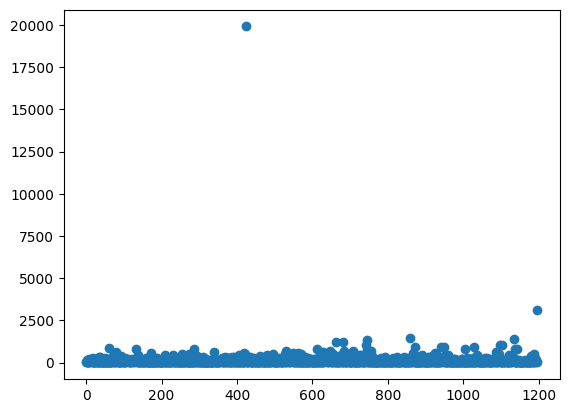

In [18]:
# %%
print(orders.sort_values(by='revenue',ascending=False).head(10))

x_values = pd.Series(range(0,len(orders['revenue'])))

plt.scatter(x_values, orders['revenue'])


 From this graph we can detect only 2 clearly anomalous orders. We get a more detailed view within the range from $0 to $1500

(0.0, 1210.0, 0.0, 1500.0)

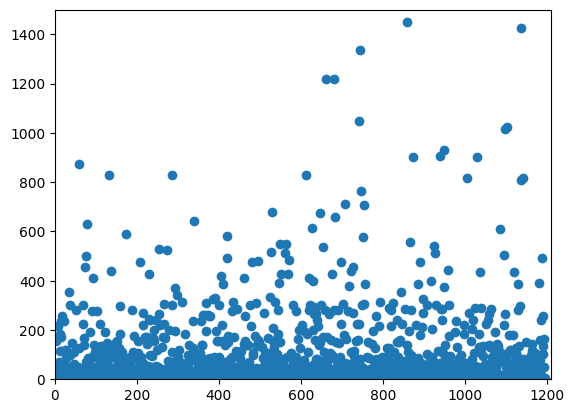

In [19]:
# %%
plt.scatter(x_values, orders['revenue'])
plt.axis([0, 1210, 0, 1500])


 We can see that $400-800 is the limit for regular orders.

 Let's calculate the 95th and 99th percentiles of order prices

In [20]:
# %%
np.percentile(orders['revenue'], [90, 95,99])


array([282.48 , 435.54 , 900.904])

 As we expected, the limit of regular orders is around $400: 5% of orders cost more than $430. We'll set this very sum as the limit

 ## Let's calculate statistical significance using the raw data

In [21]:
# %%
import scipy.stats as stats


 ### Conversion

In [24]:
# %%
ordersByUsersA = orders[orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA.columns = ['visitorId', 'orders']

ordersByUsersB = orders[orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB.columns = ['visitorId', 'orders']

sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(visitors[visitors['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(visitors[visitors['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

print("{0:.5f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))
print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))



0.01679
0.138


 Conversion in group B is greater than that of group A by 13.8%. P-value is below 0.05, so we can reject the null hypothesis and conclude that there is a statistically significant difference between the groups.

 ### Average order size

In [25]:
# %%
print("{0:.3f}".format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
print("{0:.3f}".format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1))


0.692
0.252


 P-value is above 0.05, so there is no statistically significant difference between the groups, if we consider the average order size, calculated using the "raw" data (despite the 25% difference).

 ## Collecting anomalous users

In [26]:
# %%
usersWithManyOrders = pd.concat([ordersByUsersA[ordersByUsersA['orders'] > 2]['visitorId'], ordersByUsersB[ordersByUsersB['orders'] > 2]['visitorId']], axis = 0)
usersWithExpensiveOrders = orders[orders['revenue'] > 430]['visitorId']
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis = 0).drop_duplicates().sort_values()
print(abnormalUsers.head(5))


1099    148427295
18      199603092
928     204675465
23      237748145
37      249864742
Name: visitorId, dtype: int64


 ## Calculating statistical significance of differences using the "filtered" data

 ### Conversion

In [29]:
# %%
sampleAFiltered = pd.concat([ordersByUsersA[np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(visitors[visitors['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])),name='orders')],axis=0)

sampleBFiltered = pd.concat([ordersByUsersB[np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(visitors[visitors['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])),name='orders')],axis=0)

print("{0:.5f}".format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print("{0:.3f}".format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))


0.01418
0.171


 After analyzing the "filtered" data p-value turned out to be even smaller and still below 0.05, so there is a statistically significant difference in conversion between the groups. Group B is 17.1$ better than group A

 ### Average order size

In [30]:
# %%
print("{0:.3f}".format(stats.mannwhitneyu(
    orders[np.logical_and(
        orders['group']=='A',
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'],
    orders[np.logical_and(
        orders['group']=='B',
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'])[1]))

print("{0:.3f}".format(
    orders[np.logical_and(orders['group']=='B',np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean()/
    orders[np.logical_and(
        orders['group']=='A',
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean() - 1))


0.750
-0.027


 But there is still no statistical significance in the average order size. What's important is that the "raw" data showed that the average order size in segment B was 25% bigger, and now it's 3% smaller as compared to segment A. This means anomalous orders indeed affect the test results

 ## Making a decision from the A/B test

 ### Facts

  * A/B has lasted for a month

  * During this. time period 1197 orders were made

  * The graph of difference in conversion is close to equalizing

  * The graph of the average order size hasn't equalized yet

  * Both "raw"and "filtered data" showed a statistically significant difference in conversion between the groups

  * Neither "raw"nor "filtered data" showed any statistically significant difference in the average order size between the groups

 So we can come to the conclusion that the groups have the same average purchase size, but group И has a better conversion rate. Despite the fact that the average order size graphs didn't equalize, the absence of statistically significant differences in average order size by both raw and filtered data, and a considerable reduction of difference between the groups with filtered data prompt that there is no use waiting for the graphs to equalize and that we can make a decision right now

 Hooray! We've finished our A/B test and it proved to be successful!